In [2]:
from azure.storage.blob import BlobServiceClient
import numpy as np
import io
from sklearn.model_selection import train_test_split
import os
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, GroupKFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
from collections import Counter

In [3]:
# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Blob file names
BLOB_NAMES = {
    "embeddings": "embeddings_checkpoint-592000.npy",
    "labels": "labels_checkpoint-592000.npy"
}

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

# Function to download and load .npy files
def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return np.load(io.BytesIO(blob_data)) 

# Load embeddings and labels
X = load_npy_from_azure(BLOB_NAMES["embeddings"])  # Features (embeddings)
y = load_npy_from_azure(BLOB_NAMES["labels"])      # Labels

# Print shape to verify
print("Feature matrix shape:", X.shape)  # (num_samples, embedding_dim)
print("Labels shape:", y.shape)          # (num_samples,)

# Define words and their labels
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0), ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0), ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1),
    ("grootmoeder", 0), ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0), ("jongen", 1), ("meisje", 0),
    ("jongetje", 1), ("meid", 0), ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0), ("peetvader", 1), ("peetmoeder", 0),
    ("bruidegom", 1), ("bruid", 0), ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1), ("dame", 0),
    ("kerel", 1), ("mister", 1), ("miss", 0), ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0), ("koning", 1),
    ("koningin", 0), ("lord", 1), ("lady", 0), ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0), ("mannelijk", 1), ("vrouwelijk", 0),
    ("gentleman", 1), ("gozer", 1), ("wijf", 0)
]

word_labels = dict(words_labels)
print("Word labels:", word_labels)

# Create word_to_indices mapping
word_to_indices = {}
current_idx = 0

for word, label in words_labels:
    # Count embeddings for this word
    count = 0
    start_idx = current_idx
    
    while current_idx < len(y) and y[current_idx] == label:
        count += 1
        current_idx += 1
    
    # Store indices for this word
    if count > 0:
        word_to_indices[word] = list(range(start_idx, start_idx + count))
    else:
        word_to_indices[word] = []

Feature matrix shape: (117652, 768)
Labels shape: (117652,)
Word labels: {'man': 1, 'vrouw': 0, 'broer': 1, 'zus': 0, 'zoon': 1, 'dochter': 0, 'neef': 1, 'nicht': 0, 'vader': 1, 'moeder': 0, 'opa': 1, 'oma': 0, 'kleinzoon': 1, 'kleindochter': 0, 'grootvader': 1, 'grootmoeder': 0, 'oom': 1, 'tante': 0, 'papa': 1, 'mama': 0, 'jongen': 1, 'meisje': 0, 'jongetje': 1, 'meid': 0, 'schoonvader': 1, 'schoonmoeder': 0, 'schoonzoon': 1, 'schoondochter': 0, 'stiefvader': 1, 'stiefmoeder': 0, 'stiefzoon': 1, 'stiefdochter': 0, 'peetvader': 1, 'peetmoeder': 0, 'bruidegom': 1, 'bruid': 0, 'meneer': 1, 'mevrouw': 0, 'mijnheer': 1, 'heer': 1, 'dame': 0, 'kerel': 1, 'mister': 1, 'miss': 0, 'mr': 1, 'ms': 0, 'prins': 1, 'prinses': 0, 'koning': 1, 'koningin': 0, 'lord': 1, 'lady': 0, 'baron': 1, 'barones': 0, 'hertog': 1, 'hertogin': 0, 'monnik': 1, 'non': 0, 'hijzelf': 1, 'zijzelf': 0, 'mannelijk': 1, 'vrouwelijk': 0, 'gentleman': 1, 'gozer': 1, 'wijf': 0}


## Logistic regression on all embeddings, but balanced

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import random
from collections import defaultdict, Counter

# Group = word name for each embedding
groups_raw = []
X_raw = []
y_raw = []

# Flatten X and y using all original embeddings
for word, indices in word_to_indices.items():
    for idx in indices:
        groups_raw.append(word)
        X_raw.append(X[idx])
        y_raw.append(word_labels[word])

# Downsample high-frequency words
def downsample_word_embeddings(X_raw, y_raw, groups_raw, max_samples_per_word=200):
    grouped = defaultdict(list)
    for i, word in enumerate(groups_raw):
        grouped[word].append(i)

    selected_indices = []
    for word, indices in grouped.items():
        if len(indices) > max_samples_per_word:
            indices = random.sample(indices, max_samples_per_word)
        selected_indices.extend(indices)

    X_ds = np.array([X_raw[i] for i in selected_indices])
    y_ds = np.array([y_raw[i] for i in selected_indices])
    groups_ds = np.array([groups_raw[i] for i in selected_indices])
    return X_ds, y_ds, groups_ds

X_full, y_full, groups = downsample_word_embeddings(X_raw, y_raw, groups_raw)

# GroupKFold
gkf = GroupKFold(n_splits=5)
accuracies = []

print("Running Group-Aware Cross-Validation (5-fold):\n")

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_full, y_full, groups)):
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y_full[train_idx], y_full[test_idx]
    test_groups = groups[test_idx]

    # Label distribution
    label_counts = Counter(y_test)
    print(f"Fold {fold_idx + 1} label distribution:", label_counts)

    model = LogisticRegression(max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Fold {fold_idx + 1} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Feminine", "Masculine"]))

print("="*50)
print(f"\nAverage accuracy across folds: {np.mean(accuracies):.4f}")

Running Group-Aware Cross-Validation (5-fold):

Fold 1 label distribution: Counter({0: 1003, 1: 990})
Fold 1 Accuracy: 0.7316
              precision    recall  f1-score   support

    Feminine       0.68      0.90      0.77      1003
   Masculine       0.84      0.57      0.68       990

    accuracy                           0.73      1993
   macro avg       0.76      0.73      0.72      1993
weighted avg       0.76      0.73      0.72      1993

Fold 2 label distribution: Counter({0: 1015, 1: 976})
Fold 2 Accuracy: 0.6484
              precision    recall  f1-score   support

    Feminine       0.67      0.60      0.64      1015
   Masculine       0.63      0.70      0.66       976

    accuracy                           0.65      1991
   macro avg       0.65      0.65      0.65      1991
weighted avg       0.65      0.65      0.65      1991

Fold 3 label distribution: Counter({1: 1180, 0: 814})
Fold 3 Accuracy: 0.6630
              precision    recall  f1-score   support

    Femin

## SVM on all embeddings, but balanced

In [4]:
from sklearn.model_selection import GroupKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import random
from collections import defaultdict, Counter

# Group = word name for each embedding
groups_raw = []
X_raw = []
y_raw = []

# Flatten X and y using all original embeddings
for word, indices in word_to_indices.items():
    for idx in indices:
        groups_raw.append(word)
        X_raw.append(X[idx])
        y_raw.append(word_labels[word])

# Downsample high-frequency words
def downsample_word_embeddings(X_raw, y_raw, groups_raw, max_samples_per_word=200):
    grouped = defaultdict(list)
    for i, word in enumerate(groups_raw):
        grouped[word].append(i)

    selected_indices = []
    for word, indices in grouped.items():
        if len(indices) > max_samples_per_word:
            indices = random.sample(indices, max_samples_per_word)
        selected_indices.extend(indices)

    X_ds = np.array([X_raw[i] for i in selected_indices])
    y_ds = np.array([y_raw[i] for i in selected_indices])
    groups_ds = np.array([groups_raw[i] for i in selected_indices])
    return X_ds, y_ds, groups_ds

X_full, y_full, groups = downsample_word_embeddings(X_raw, y_raw, groups_raw)

word_counts = Counter(groups)
print("Word counts after downsampling:")
for word, count in word_counts.items():
    print(f"{word}: {count}")

# GroupKFold: ensures same word isn't in both train/test
gkf = GroupKFold(n_splits=5)
accuracies = []

print("Running Group-Aware Cross-Validation (5-fold) with SVM:\n")

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_full, y_full, groups)):
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y_full[train_idx], y_full[test_idx]
    test_groups = groups[test_idx]

    # Label distribution
    label_counts = Counter(y_test)
    print(f"Fold {fold_idx + 1} label distribution:", label_counts)

    # Use a linear SVM
    model = SVC(kernel='linear', random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Fold {fold_idx + 1} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Feminine", "Masculine"]))

print("="*50)
print(f"\nAverage accuracy across folds: {np.mean(accuracies):.4f}")

Word counts after downsampling:
man: 200
vrouw: 200
broer: 200
zus: 200
zoon: 200
dochter: 200
neef: 200
nicht: 200
vader: 200
moeder: 200
opa: 200
oma: 200
kleinzoon: 200
kleindochter: 200
grootvader: 200
grootmoeder: 200
oom: 200
tante: 200
papa: 200
mama: 200
jongen: 200
meisje: 200
jongetje: 200
meid: 200
schoonvader: 174
schoonmoeder: 200
schoonzoon: 149
schoondochter: 129
stiefvader: 61
stiefmoeder: 44
stiefzoon: 10
stiefdochter: 6
peetvader: 14
peetmoeder: 3
bruidegom: 189
bruid: 200
meneer: 200
mevrouw: 200
mijnheer: 200
dame: 200
kerel: 200
miss: 150
mr: 200
ms: 6
prins: 200
prinses: 200
koning: 200
koningin: 200
lord: 71
lady: 80
baron: 136
barones: 8
hertog: 176
hertogin: 37
monnik: 120
non: 200
hijzelf: 200
zijzelf: 167
mannelijk: 200
vrouwelijk: 200
gentleman: 70
wijf: 168
Running Group-Aware Cross-Validation (5-fold) with SVM:

Fold 1 label distribution: Counter({0: 1003, 1: 990})
Fold 1 Accuracy: 0.9047
              precision    recall  f1-score   support

    Feminine 

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import numpy as np
import random
from collections import defaultdict, Counter
import joblib
import os

# Ensure the directory to save models exists
os.makedirs("svm_models_checkpoint100_BERT", exist_ok=True)

# Group = word name for each embedding
groups_raw = []
X_raw = []
y_raw = []

# Flatten X and y using all original embeddings
for word, indices in word_to_indices.items():
    for idx in indices:
        groups_raw.append(word)
        X_raw.append(X[idx])
        y_raw.append(word_labels[word])

# Downsample high-frequency words
def downsample_word_embeddings(X_raw, y_raw, groups_raw, max_samples_per_word=200):
    grouped = defaultdict(list)
    for i, word in enumerate(groups_raw):
        grouped[word].append(i)

    selected_indices = []
    for word, indices in grouped.items():
        if len(indices) > max_samples_per_word:
            indices = random.sample(indices, max_samples_per_word)
        selected_indices.extend(indices)

    X_ds = np.array([X_raw[i] for i in selected_indices])
    y_ds = np.array([y_raw[i] for i in selected_indices])
    groups_ds = np.array([groups_raw[i] for i in selected_indices])
    return X_ds, y_ds, groups_ds

X_full, y_full, groups = downsample_word_embeddings(X_raw, y_raw, groups_raw)

word_counts = Counter(groups)
print("Word counts after downsampling:")
for word, count in word_counts.items():
    print(f"{word}: {count}")

# GroupKFold: ensures same word isn't in both train/test
gkf = GroupKFold(n_splits=5)
accuracies = []

print("Running Group-Aware Cross-Validation (5-fold) with SVM:\n")

for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X_full, y_full, groups)):
    X_train, X_test = X_full[train_idx], X_full[test_idx]
    y_train, y_test = y_full[train_idx], y_full[test_idx]
    test_groups = groups[test_idx]

    # Label distribution
    label_counts = Counter(y_test)
    print(f"Fold {fold_idx + 1} label distribution:", label_counts)

    # Use a linear SVM
    model = SVC(kernel='linear', random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Fold {fold_idx + 1} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=["Feminine", "Masculine"]))

    # Save model
    model_path = f"svm_models_checkpoint100_BERT/svm_model_fold_{fold_idx + 1}.joblib"
    joblib.dump(model, model_path)
    print(f"Saved model for Fold {fold_idx + 1} to {model_path}")

print("="*50)
print(f"\nAverage accuracy across folds: {np.mean(accuracies):.4f}")

# ================================
# Train Final Model on All Data
# ================================

final_model = SVC(kernel='linear', random_state=42)
final_model.fit(X_full, y_full)

final_model_path = "svm_models_checkpoint100_BERT/svm_final_model.joblib"
joblib.dump(final_model, final_model_path)
print(f"\nFinal model trained on all data and saved to {final_model_path}")

# ================================
# Load Final Model & Use It
# ================================

# Load the final model
final_model_loaded = joblib.load(final_model_path)
print("Final model loaded.")

# Access coefficients
print("Final model weight vector (coef_):")
print(final_model_loaded.coef_[0])


Word counts after downsampling:
man: 200
vrouw: 200
broer: 200
zus: 200
zoon: 200
dochter: 200
neef: 200
nicht: 200
vader: 200
moeder: 200
opa: 200
oma: 200
kleinzoon: 200
kleindochter: 200
grootvader: 200
grootmoeder: 200
oom: 200
tante: 200
papa: 200
mama: 200
jongen: 200
meisje: 200
jongetje: 200
meid: 200
schoonvader: 174
schoonmoeder: 200
schoonzoon: 149
schoondochter: 129
stiefvader: 61
stiefmoeder: 44
stiefzoon: 10
stiefdochter: 6
peetvader: 14
peetmoeder: 3
bruidegom: 189
bruid: 200
meneer: 200
mevrouw: 200
mijnheer: 200
dame: 200
kerel: 200
miss: 150
mr: 200
ms: 6
prins: 200
prinses: 200
koning: 200
koningin: 200
lord: 71
lady: 80
baron: 136
barones: 8
hertog: 176
hertogin: 37
monnik: 120
non: 200
hijzelf: 200
zijzelf: 167
mannelijk: 200
vrouwelijk: 200
gentleman: 70
wijf: 168
Running Group-Aware Cross-Validation (5-fold) with SVM:

Fold 1 label distribution: Counter({0: 1003, 1: 990})
Fold 1 Accuracy: 0.9157
              precision    recall  f1-score   support

    Feminine 

## SVM on all embeddings, but balanced, for every checkpoint

In [ ]:
import os
import io
import re
import json
import numpy as np
import random
from collections import defaultdict, Counter
from azure.storage.blob import BlobServiceClient
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Azure Storage account details
AZURE_STORAGE_CONNECTION_STRING = os.getenv("SONAR_STORAGE_KEY")
CONTAINER_NAME = "svmdata"

# Initialize BlobServiceClient
blob_service_client = BlobServiceClient.from_connection_string(AZURE_STORAGE_CONNECTION_STRING)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

def load_npy_from_azure(blob_name):
    blob_client = container_client.get_blob_client(blob_name)
    blob_data = blob_client.download_blob().readall()
    return np.load(io.BytesIO(blob_data))

# Word-label pairs
words_labels = [
    ("man", 1), ("vrouw", 0), ("broer", 1), ("zus", 0), ("zoon", 1), ("dochter", 0), ("neef", 1), ("nicht", 0),
    ("vader", 1), ("moeder", 0), ("opa", 1), ("oma", 0), ("kleinzoon", 1), ("kleindochter", 0), ("grootvader", 1),
    ("grootmoeder", 0), ("oom", 1), ("tante", 0), ("papa", 1), ("mama", 0), ("jongen", 1), ("meisje", 0),
    ("jongetje", 1), ("meid", 0), ("schoonvader", 1), ("schoonmoeder", 0), ("schoonzoon", 1), ("schoondochter", 0),
    ("stiefvader", 1), ("stiefmoeder", 0), ("stiefzoon", 1), ("stiefdochter", 0), ("peetvader", 1), ("peetmoeder", 0),
    ("bruidegom", 1), ("bruid", 0), ("meneer", 1), ("mevrouw", 0), ("mijnheer", 1), ("heer", 1), ("dame", 0),
    ("kerel", 1), ("mister", 1), ("miss", 0), ("mr", 1), ("ms", 0), ("prins", 1), ("prinses", 0), ("koning", 1),
    ("koningin", 0), ("lord", 1), ("lady", 0), ("baron", 1), ("barones", 0), ("hertog", 1), ("hertogin", 0),
    ("monnik", 1), ("non", 0), ("hijzelf", 1), ("zijzelf", 0), ("mannelijk", 1), ("vrouwelijk", 0),
    ("gentleman", 1), ("gozer", 1), ("wijf", 0)
]
word_labels = dict(words_labels)

def downsample_word_embeddings(X_raw, y_raw, groups_raw, max_samples_per_word=200):
    grouped = defaultdict(list)
    for i, word in enumerate(groups_raw):
        grouped[word].append(i)

    selected_indices = []
    for word, indices in grouped.items():
        if len(indices) > max_samples_per_word:
            indices = random.sample(indices, max_samples_per_word)
        selected_indices.extend(indices)

    X_ds = np.array([X_raw[i] for i in selected_indices])
    y_ds = np.array([y_raw[i] for i in selected_indices])
    groups_ds = np.array([groups_raw[i] for i in selected_indices])
    return X_ds, y_ds, groups_ds

def run_group_kfold(X, y, groups, checkpoint_id):
    gkf = GroupKFold(n_splits=5)
    fold_accuracies = []
    fold_reports = []

    for fold_idx, (train_idx, test_idx) in enumerate(gkf.split(X, y, groups)):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model = LogisticRegression(max_iter=1000, random_state=42)
        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, target_names=["Feminine", "Masculine"], output_dict=True)

        fold_accuracies.append(acc)
        fold_reports.append({
            "fold": fold_idx + 1,
            "accuracy": acc,
            "classification_report": report,
            "label_distribution": dict(Counter(y_test))
        })

    result = {
        "checkpoint": checkpoint_id,
        "average_accuracy": float(np.mean(fold_accuracies)),
        "folds": fold_reports
    }
    return result

# Discover all embedding-label pairs
blobs = container_client.list_blobs()
embedding_blobs = []
label_blobs = {}

for blob in blobs:
    if re.match(r"embeddings_checkpoint-\d+\.npy", blob.name):
        checkpoint_id = int(re.findall(r"\d+", blob.name)[0])
        embedding_blobs.append((checkpoint_id, blob.name))
    elif re.match(r"labels_checkpoint-\d+\.npy", blob.name):
        checkpoint_id = int(re.findall(r"\d+", blob.name)[0])
        label_blobs[checkpoint_id] = blob.name

# Store all results here
all_results = []

for checkpoint_id, embedding_blob in sorted(embedding_blobs):
    if checkpoint_id not in label_blobs:
        continue

    print(f"\n>>> Processing checkpoint {checkpoint_id}...")

    X = load_npy_from_azure(embedding_blob)
    y = load_npy_from_azure(label_blobs[checkpoint_id])

    # Map word -> embedding indices
    word_to_indices = {}
    current_idx = 0
    for word, label in words_labels:
        count = 0
        start_idx = current_idx
        while current_idx < len(y) and y[current_idx] == label:
            count += 1
            current_idx += 1
        word_to_indices[word] = list(range(start_idx, start_idx + count)) if count > 0 else []

    # Flatten embeddings + labels
    X_raw, y_raw, groups_raw = [], [], []
    for word, indices in word_to_indices.items():
        for idx in indices:
            groups_raw.append(word)
            X_raw.append(X[idx])
            y_raw.append(word_labels[word])

    X_full, y_full, groups = downsample_word_embeddings(X_raw, y_raw, groups_raw)
    result = run_group_kfold(X_full, y_full, groups, checkpoint_id)
    print(f"Average accuracy for checkpoint {checkpoint_id}: {result['average_accuracy']:.8f}")
    all_results.append(result)

def convert_keys_to_str(obj):
    if isinstance(obj, dict):
        return {str(k): convert_keys_to_str(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_keys_to_str(i) for i in obj]
    else:
        return obj

# Convert before saving
clean_results = convert_keys_to_str(all_results)

# Save to JSON
with open("results_gender_classification.json", "w") as f:
    json.dump(clean_results, f, indent=2)

print("\nAll checkpoint evaluations complete. Results saved to 'results_gender_classification.json'.")


>>> Processing checkpoint 296...
Average accuracy for checkpoint 296: 0.49072648

>>> Processing checkpoint 592...
Average accuracy for checkpoint 592: 0.47810318

>>> Processing checkpoint 888...
Average accuracy for checkpoint 888: 0.49765233

>>> Processing checkpoint 1184...
Average accuracy for checkpoint 1184: 0.49166713

>>> Processing checkpoint 1480...
Average accuracy for checkpoint 1480: 0.48112408

>>> Processing checkpoint 1776...
Average accuracy for checkpoint 1776: 0.47882966

>>> Processing checkpoint 2072...
Average accuracy for checkpoint 2072: 0.48657558

>>> Processing checkpoint 2368...
Average accuracy for checkpoint 2368: 0.48657523

>>> Processing checkpoint 2664...
Average accuracy for checkpoint 2664: 0.51466959

>>> Processing checkpoint 2960...
Average accuracy for checkpoint 2960: 0.51594919

>>> Processing checkpoint 3256...
Average accuracy for checkpoint 3256: 0.49617629

>>> Processing checkpoint 3552...
Average accuracy for checkpoint 3552: 0.4776194

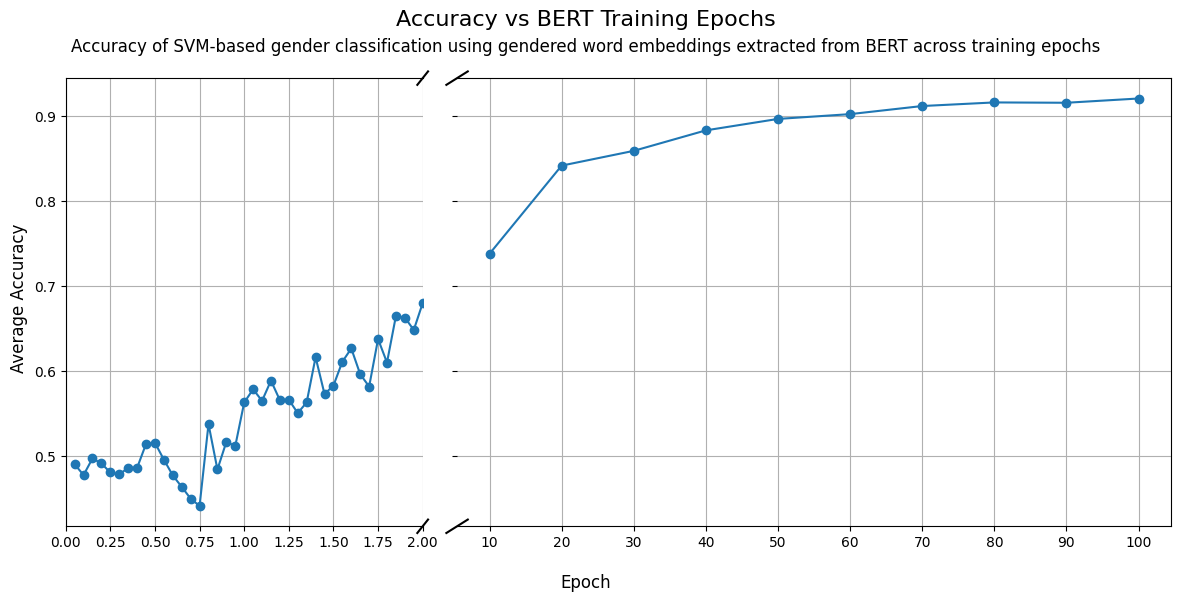

In [ ]:
import json
import matplotlib.pyplot as plt

# Load the data
with open('results_gender_classification.json', 'r') as f:
    data = json.load(f)

# Constants
steps_per_epoch = 5920

# Data holders
x_left = []
y_left = []

x_right = []
y_right = []

for entry in data:
    step = entry['checkpoint']
    acc = entry['average_accuracy']
    
    if step <= 11840:  # up to 2 epochs
        percent = (step / steps_per_epoch)
        x_left.append(percent)
        y_left.append(acc)
    else:
        if step <= 592000: # up to 100
            epoch = step // steps_per_epoch
            if epoch % 10 == 0:  # only every 10 epochs
                x_right.append(epoch)
                y_right.append(acc)

# Plot with broken axis
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [1, 2]})

# Left axis: percentage of first epoch
ax1.plot(x_left, y_left, marker='o')
ax1.grid(True)
ax1.set_xlim(0, 2)

# Right axis: full epoch numbers (every 10)
ax2.plot(x_right, y_right, marker='o')
ax2.grid(True)
ax2.set_xticks(x_right)  # show only the filtered epochs

# Break visual
ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax1.tick_params(labelright=False)
ax2.tick_params(labelleft=False)

# Set titles
fig.suptitle('Accuracy vs BERT Training Epochs\n', fontsize=16)
fig.text(0.5, 0.91, 
         'Accuracy of SVM-based gender classification using gendered word embeddings extracted from BERT across training epochs', 
         ha='center', fontsize=12)
fig.supxlabel('Epoch')
fig.supylabel('Average Accuracy')

# Diagonal cut marks
d = .015
kwargs = dict(transform=ax1.transAxes, color='k', clip_on=False)
ax1.plot((1 - d, 1 + d), (-d, +d), **kwargs)
ax1.plot((1 - d, 1 + d), (1 - d, 1 + d), **kwargs)

kwargs.update(transform=ax2.transAxes)
ax2.plot((-d, +d), (-d, +d), **kwargs)
ax2.plot((-d, +d), (1 - d, 1 + d), **kwargs)

plt.tight_layout()
plt.show()